## Temporal Analysis of Tracks


In [1]:
import zipfile
import os

# Path to your uploaded zip file
zip_path = "spotify_data.zip"  

# Directory where you want to extract
extract_dir = "unzipped_folder"

# Create folder if not exists
os.makedirs(extract_dir, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Files extracted to:", extract_dir)

Files extracted to: unzipped_folder


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
# csv_file = os.path.join(extract_dir, "Spotify_Dataset_V3.csv")

# # Read CSV with semicolon delimiter
# df = pd.read_csv(csv_file, sep=";", engine="python")

df = pd.read_csv(r'../data/Spotify_Dataset_V3.csv', delimiter=';')

print(df.head())
print("\nColumns:", df.columns.tolist())

   Rank            Title                     Artists        Date  \
0     1  Ella Baila Sola  Eslabon Armado, Peso Pluma  29/05/2023   
1     1  Ella Baila Sola  Eslabon Armado, Peso Pluma  29/05/2023   
2     2   WHERE SHE GOES                   Bad Bunny  29/05/2023   
3     3  La Bebe - Remix       Yng Lvcas, Peso Pluma  29/05/2023   
4     3  La Bebe - Remix       Yng Lvcas, Peso Pluma  29/05/2023   

   Danceability  Energy  Loudness  Speechiness  Acousticness  \
0         0.668   0.758   -5176.0        0.033         0.483   
1         0.668   0.758   -5176.0        0.033         0.483   
2         0.652   0.800   -4019.0        0.061         0.143   
3         0.812   0.479   -5678.0        0.333         0.213   
4         0.812   0.479   -5678.0        0.333         0.213   

   Instrumentalness  Valence # of Artist   Artist (Ind.) # of Nationality  \
0             0.000    0.834    Artist 1  Eslabon Armado    Nationality 1   
1             0.000    0.834    Artist 2      Peso P

## Temporal Analysis


In [4]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# load Data 
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.shape, df.columns

((651936, 20),
 Index(['Rank', 'Title', 'Artists', 'Date', 'Danceability', 'Energy',
        'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness',
        'Valence', '# of Artist', 'Artist (Ind.)', '# of Nationality',
        'Nationality', 'Continent', 'Points (Total)',
        'Points (Ind for each Artist/Nat)', 'id', 'Song URL'],
       dtype='object'))

In [5]:
# Remove any rows with invalid dates (if present)
df = df.dropna(subset=['Date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651936 entries, 0 to 651935
Data columns (total 20 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   Rank                              651936 non-null  int64         
 1   Title                             651936 non-null  object        
 2   Artists                           651936 non-null  object        
 3   Date                              651936 non-null  datetime64[ns]
 4   Danceability                      651936 non-null  float64       
 5   Energy                            651936 non-null  float64       
 6   Loudness                          651936 non-null  float64       
 7   Speechiness                       651936 non-null  float64       
 8   Acousticness                      651936 non-null  float64       
 9   Instrumentalness                  651936 non-null  float64       
 10  Valence                         

In [7]:
# Create new time-based columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Week'] = df['Date'].dt.isocalendar().week


In [8]:
df = df[df['Year'] < 2023]


In [9]:
day_trends = (
    df.groupby('Day_of_Week')['Points (Total)']
    .sum()
    .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
)

print(day_trends)


Day_of_Week
Monday       8694074
Tuesday      8691338
Wednesday    8706934
Thursday     8729148
Friday       8751691
Saturday     8888057
Sunday       8759639
Name: Points (Total), dtype: int64


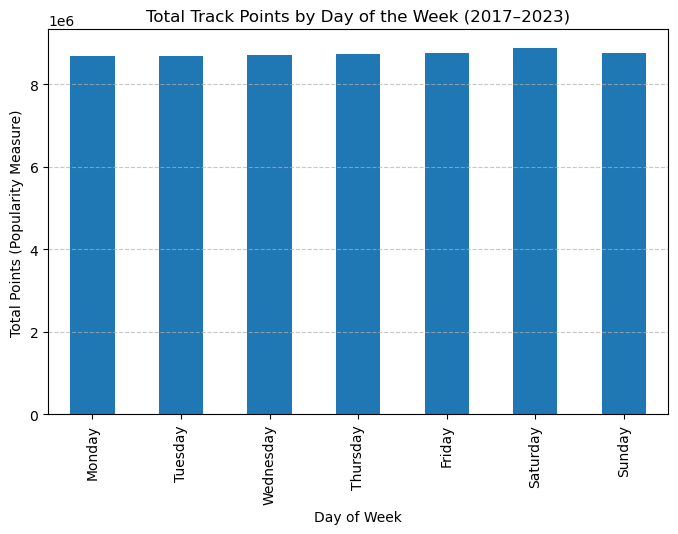

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
day_trends.plot(kind='bar')
plt.title("Total Track Points by Day of the Week (2017–2023)")
plt.xlabel("Day of Week")
plt.ylabel("Total Points (Popularity Measure)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Month Trends

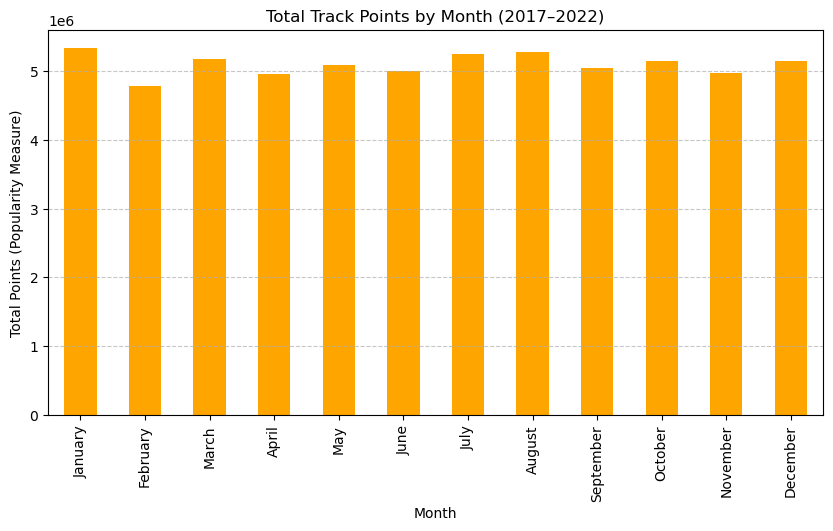

Month
January      5333955
February     4778920
March        5181993
April        4965300
May          5095301
June         5006847
July         5254978
August       5280835
September    5051242
October      5145390
November     4974437
December     5151683
Name: Points (Total), dtype: int64

In [11]:
month_trends = (
    df.groupby('Month')['Points (Total)']
    .sum()
    .reindex([
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ])
)

plt.figure(figsize=(10, 5))
month_trends.plot(kind='bar', color='orange')
plt.title("Total Track Points by Month (2017–2022)")
plt.xlabel("Month")
plt.ylabel("Total Points (Popularity Measure)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
month_trends 

In [12]:
unique_songs_per_year = (
    df.groupby('Year')['Title']
    .nunique()
    .reset_index()
    .rename(columns={'id': 'Number_of_Unique_Songs'})
)
unique_songs_per_year

,Year,Title
0,2017,1310
1,2018,1619
2,2019,1518
3,2020,1776
4,2021,1637
5,2022,1433


## Yearly Trends

In [13]:

song_year = (
    df.groupby(['Year', 'Title'])
      ['Points (Total)'].sum()
      .reset_index()
)
yearly_summary = (
    song_year.groupby('Year')
             .agg(Number_of_Unique_Songs=('Title', 'nunique'),
                  Total_Points=('Points (Total)', 'sum'))
             .reset_index()
)
yearly_summary


,Year,Number_of_Unique_Songs,Total_Points
0,2017,1310,9818064
1,2018,1619,10368011
2,2019,1518,10619250
3,2020,1776,9792540
4,2021,1637,9879331
5,2022,1433,10743685


In [14]:
days_per_year = df.groupby('Year')['Date'].nunique().reset_index(name='unique_days')
print(days_per_year)
song_year = df.groupby(['Year', 'Title'])['Points (Total)'].sum().reset_index()
avg_points = song_year.groupby('Year')['Points (Total)'].mean().reset_index(name='avg_points_per_song')
print(avg_points)
df.groupby(['Year','Month'])['Date'].count().unstack(fill_value=0)

   Year  unique_days
0  2017          361
1  2018          365
2  2019          365
3  2020          366
4  2021          365
5  2022          365
   Year  avg_points_per_song
0  2017          7494.705344
1  2018          6403.959852
2  2019          6995.553360
3  2020          5513.817568
4  2021          6035.021991
5  2022          7497.337753


Month,April,August,December,February,January,July,June,March,May,November,October,September
Year,,,,,,,,,,,,
2017,7831,8296,8765,7121,8099,8259,7743,8097,7616,8318,8321,7962
2018,8510,8406,8720,8208,9135,8646,8315,9003,8670,8569,8606,8353
2019,8357,9572,8854,7842,8661,9343,8561,8667,8627,8530,9207,9009
2020,8031,8253,7879,8161,8911,8230,8155,8108,8488,7612,8239,8189
2021,8117,8468,8561,7198,7927,8525,8209,8375,8426,7987,8336,8087
2022,9260,8895,8899,9291,10381,8934,8368,9801,8826,8273,8525,8423


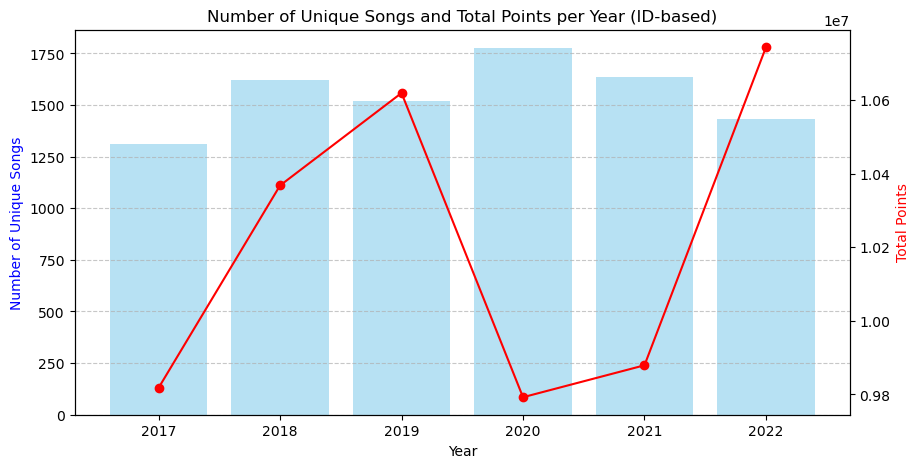

In [15]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(yearly_summary['Year'], yearly_summary['Number_of_Unique_Songs'], 
        alpha=0.6, label='Unique Songs (ID-based)', color='skyblue')

ax2 = ax1.twinx()
ax2.plot(yearly_summary['Year'], yearly_summary['Total_Points'], 
         color='red', marker='o', label='Total Points')

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Unique Songs', color='blue')
ax2.set_ylabel('Total Points', color='red')
ax1.set_title('Number of Unique Songs and Total Points per Year (ID-based)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


C:\Users\govin\AppData\Local\Temp\ipykernel_52264\3911651470.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key='Date', freq='M'))['Points (Total)']


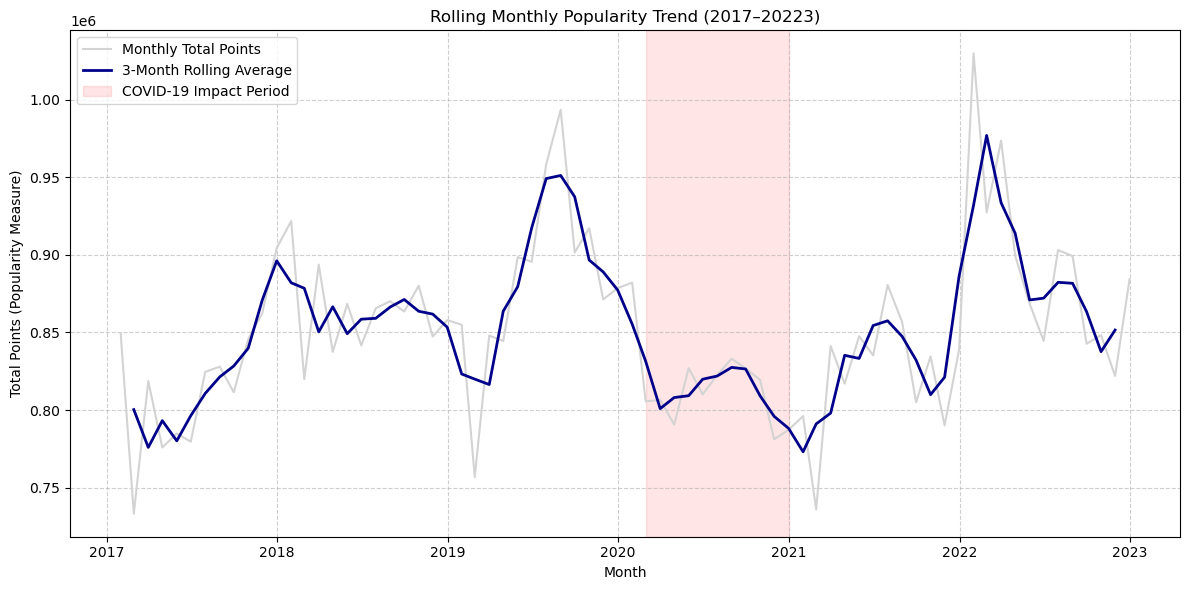

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Date column is datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Group by month (using the first day of each month for clarity)
monthly_trends = (
    df.groupby(pd.Grouper(key='Date', freq='M'))['Points (Total)']
      .sum()
      .reset_index()
)

# Compute rolling average (window = 3 months → smoother line)
monthly_trends['Rolling_3M'] = monthly_trends['Points (Total)'].rolling(window=3, center=True).mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_trends['Date'], monthly_trends['Points (Total)'],
         color='lightgray', label='Monthly Total Points')
plt.plot(monthly_trends['Date'], monthly_trends['Rolling_3M'],
         color='darkblue', linewidth=2, label='3-Month Rolling Average')

# Annotate COVID period (March 2020–Dec 2020)
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'),
            color='red', alpha=0.1, label='COVID-19 Impact Period')

plt.title("Rolling Monthly Popularity Trend (2017–20223)")
plt.xlabel("Month")
plt.ylabel("Total Points (Popularity Measure)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


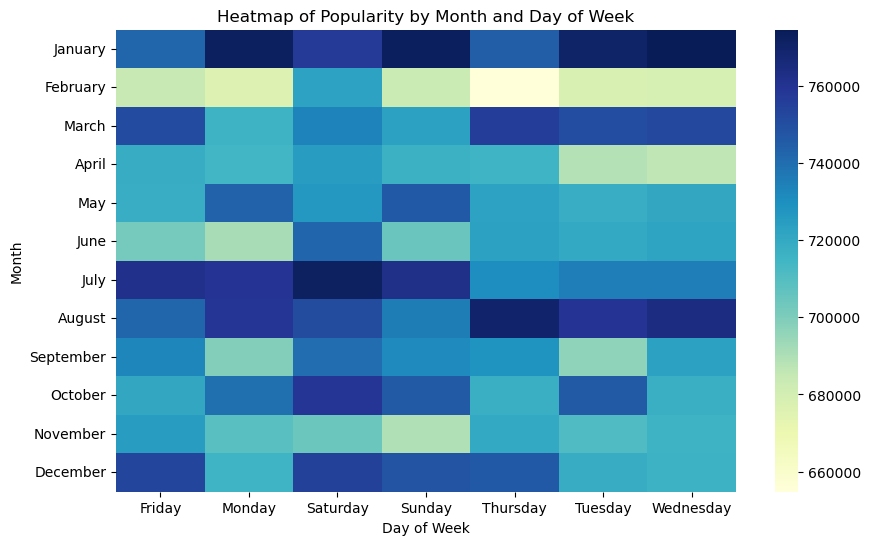

In [19]:
import seaborn as sns

heatmap_data = (
    df.pivot_table(
        values='Points (Total)',
        index='Month',
        columns='Day_of_Week',
        aggfunc='sum'
    )
    .reindex([
        'January','February','March','April','May','June','July','August',
        'September','October','November','December'
    ])
    .fillna(0)
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Heatmap of Popularity by Month and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Month")
plt.show()


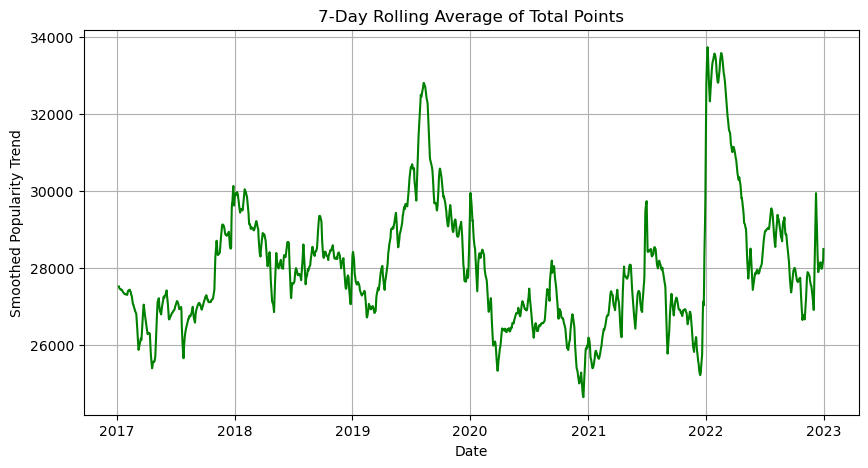

In [96]:
weekly_points = df.groupby('Date')['Points (Total)'].sum().sort_index()
rolling_trend = weekly_points.rolling(window=7).mean()

plt.figure(figsize=(10, 5))
plt.plot(rolling_trend.index, rolling_trend.values, color='green')
plt.title("7-Day Rolling Average of Total Points")
plt.xlabel("Date")
plt.ylabel("Smoothed Popularity Trend")
plt.grid(True)
plt.show()


C:\Users\govin\AppData\Local\Temp\ipykernel_12756\3758857519.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['# of Artist'] = df['# of Artist'].astype(str).str.extract('(\d+)').astype(float)


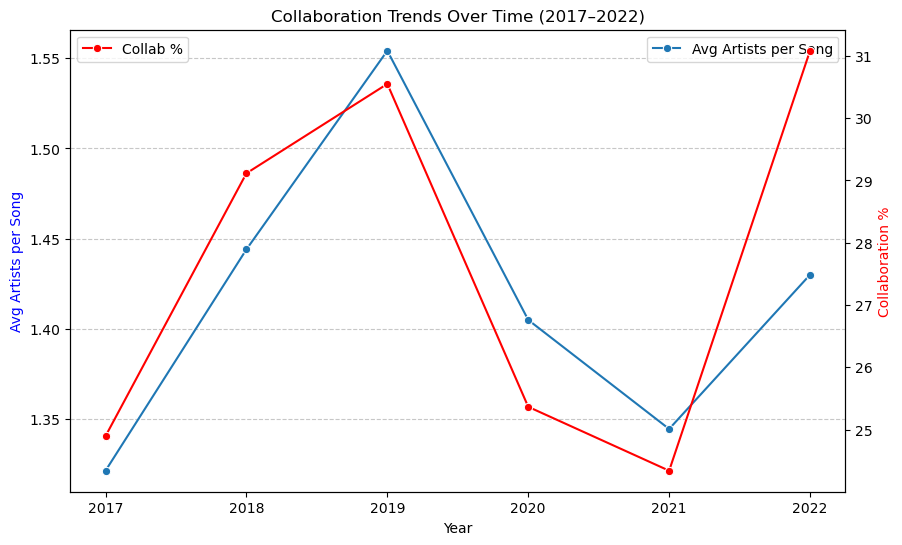

,Year,Avg_Artists_Per_Song,Collaboration_%
0,2017,1.321245,24.894222
1,2018,1.443984,29.114513
2,2019,1.554177,30.550223
3,2020,1.404881,25.365372
4,2021,1.344394,24.339212
5,2022,1.429947,31.082910


In [56]:
# Compute number of artists per song per year
df['# of Artist'] = df['# of Artist'].astype(str).str.extract('(\d+)').astype(float)
collab_yearly = (
    df.groupby('Year')['# of Artist']
    .mean()
    .reset_index()
    .rename(columns={'# of Artist': 'Avg_Artists_Per_Song'})
)

# Calculate percentage of collaborations (songs with >1 artist)
collab_percentage = (
    df.groupby('Year')['# of Artist']
    .apply(lambda x: (x > 1).sum() / len(x) * 100)
    .reset_index()
    .rename(columns={'# of Artist': 'Collaboration_%'})
)

# Merge both
collab_trends = pd.merge(collab_yearly, collab_percentage, on='Year')

# Plot
fig, ax1 = plt.subplots(figsize=(10,6))
sns.lineplot(data=collab_trends, x='Year', y='Avg_Artists_Per_Song', marker='o', label='Avg Artists per Song', ax=ax1)
ax2 = ax1.twinx()
sns.lineplot(data=collab_trends, x='Year', y='Collaboration_%', color='red', marker='o', label='Collab %', ax=ax2)

ax1.set_title("Collaboration Trends Over Time (2017–2022)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Avg Artists per Song", color='blue')
ax2.set_ylabel("Collaboration %", color='red')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

collab_trends


## Longetivity of the Songs by year

In [20]:
# Group by song ID to find how many unique days it appeared
song_longevity = (
    df.groupby('id')['Date']
    .nunique()
    .reset_index()
    .rename(columns={'Date': 'Days_in_Chart'})
)

# Merge back to get year of first appearance
first_appearance = (
    df.groupby('id')['Date']
    .min()
    .reset_index()
    .rename(columns={'Date': 'First_Appearance'})
)

song_longevity = song_longevity.merge(first_appearance, on='id', how='left')
song_longevity['Year'] = song_longevity['First_Appearance'].dt.year
song_longevity

,id,Days_in_Chart,First_Appearance,Year
0,000xQL6tZNLJzIrtIgxqSl,118,2017-03-24,2017
1,003VDDA7J3Xb2ZFlNx7nIZ,2,2020-02-07,2020
2,003eoIwxETJujVWmNFMoZy,14,2018-06-15,2018
3,003vvx7Niy0yvhvHt4a68B,559,2020-08-15,2020
4,00B7TZ0Xawar6NZ00JFomN,14,2018-04-06,2018
...,...,...,...,...
8715,7zjEyeBsaw9gV0jofJLfOM,8,2021-10-15,2021
8716,7zl7kehxesNEo2pYkKXTSe,4,2021-05-30,2021
8717,7znO2T2deQ7nZUbyxEAMDB,1,2019-08-09,2019
8718,7zvfDihYiJ8RQ1nRcpKBF5,8,2022-05-13,2022


In [21]:
longevity_by_year = (
    song_longevity.groupby('Year')['Days_in_Chart']
    .mean()
    .reset_index()
    .rename(columns={'Days_in_Chart': 'Avg_Longevity_Days'})
)
longevity_by_year


,Year,Avg_Longevity_Days
0,2017,72.871696
1,2018,53.573980
2,2019,53.117066
3,2020,42.345466
4,2021,42.201556
5,2022,31.970383


In [61]:
songs_per_year = (
    df.groupby('Year')['id']
    .nunique()
    .reset_index()
    .rename(columns={'id': 'Unique_Songs'})
)

# Approximate turnover rate as the number of debut songs
turnover_rate = (
    song_longevity.groupby('Year')['id']
    .count()
    .reset_index()
    .rename(columns={'id': 'New_Songs_Entered'})
)

# Merge the two
turnover_trends = pd.merge(longevity_by_year, songs_per_year, on='Year', how='outer')
turnover_trends = pd.merge(turnover_trends, turnover_rate, on='Year', how='outer')

# Optional: compute normalized turnover ratio
turnover_trends['Turnover_Rate_%'] = (
    turnover_trends['New_Songs_Entered'] / turnover_trends['Unique_Songs'] * 100
)
turnover_trends

,Year,Avg_Longevity_Days,Unique_Songs,New_Songs_Entered,Turnover_Rate_%
0,2017,72.871696,1551,1551,100.000000
1,2018,53.573980,1924,1568,81.496881
2,2019,53.117066,1765,1418,80.339943
3,2020,42.345466,2004,1621,80.888224
4,2021,42.201556,1822,1414,77.607025
5,2022,31.970383,1589,1148,72.246696


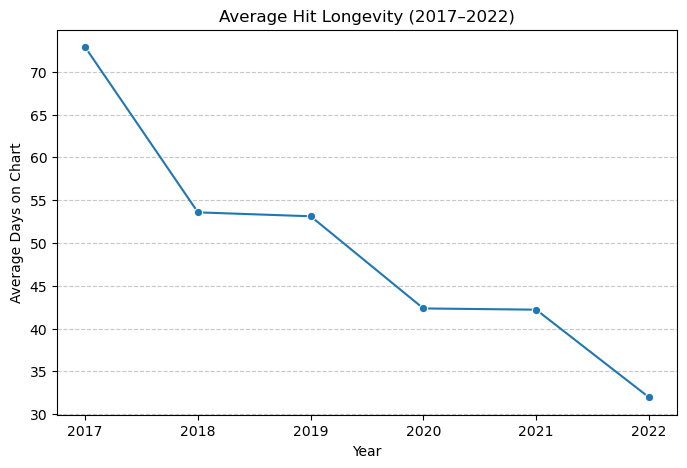

In [142]:
plt.figure(figsize=(8,5))
sns.lineplot(data=longevity_by_year, x='Year', y='Avg_Longevity_Days', marker='o')
plt.title("Average Hit Longevity (2017–2022)")
plt.xlabel("Year")
plt.ylabel("Average Days on Chart")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


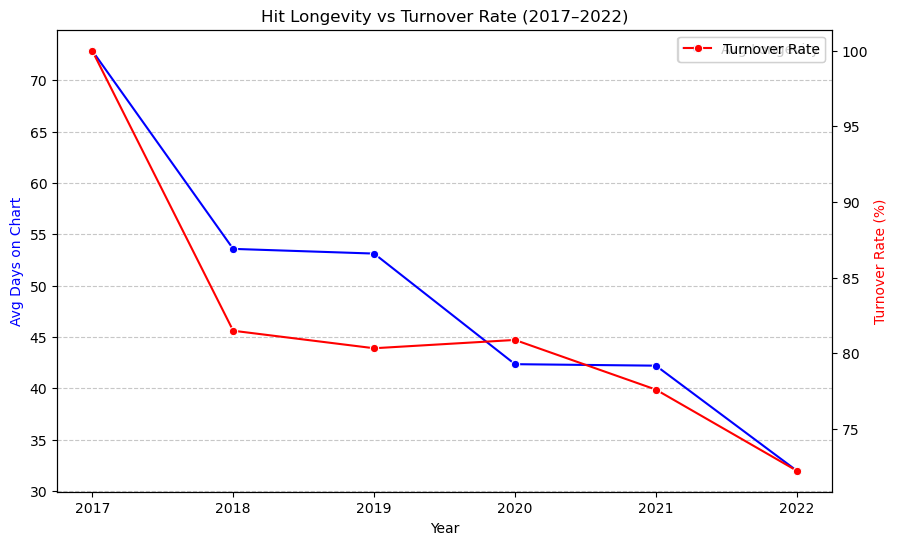

In [145]:
fig, ax1 = plt.subplots(figsize=(10,6))
sns.lineplot(data=longevity_by_year, x='Year', y='Avg_Longevity_Days', marker='o', color='blue', label='Avg Longevity', ax=ax1)
ax2 = ax1.twinx()
sns.lineplot(data=turnover_trends, x='Year', y='Turnover_Rate_%', marker='o', color='red', label='Turnover Rate', ax=ax2)

ax1.set_title("Hit Longevity vs Turnover Rate (2017–2022)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Avg Days on Chart", color='blue')
ax2.set_ylabel("Turnover Rate (%)", color='red')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
